# Risk Measures Under Catastrophic Tail Variation: VaR vs CVaR

This experiment investigates whether standard risk measures adequately capture catastrophic tail risks by comparing **Value at Risk (VaR)** and **Conditional Value at Risk (CVaR)** as the Pareto tail index $\alpha$ of the catastrophic loss component varies from 3.0 (thin tail) to 1.5 (heavy tail).

## Motivation

Insurance portfolios face a spectrum of loss severities. Attritional and large losses are well-behaved (finite variance, lognormal), but catastrophic events follow power-law distributions where the tail index $\alpha$ governs how extreme the worst outcomes can be:

| Regime | Behaviour |
|---|---|
| **$\alpha > 2$** | Finite mean *and* variance. Standard actuarial tools work well. |
| **$1 < \alpha \leq 2$** | Finite mean but *infinite variance*. Expected loss is well-defined, but variance diverges. |
| **$\alpha \leq 1$** | Even the mean diverges. (Not explored here.) |

The critical transition at $\alpha = 2$ is where this experiment operates. Our baseline configuration uses $\alpha = 2.01$, sitting right at the edge of finite variance. As we push $\alpha$ downward toward 1.5, we enter infinite-variance territory where tail risk grows explosively — but the mean stays constant.

## Experiment Design

We use the loss configuration from the deductible optimization experiment (Notebook 12), extracting the three-component compound-Poisson loss model. We vary only the catastrophic component's tail index $\alpha$ from 3.0 to 1.5, adjusting $x_m$ to keep the component mean constant:

$$E[X_{\text{cat}}] = \frac{\alpha \cdot x_m}{\alpha - 1} = \text{const} \implies x_m(\alpha) = \bar{X}_{\text{cat}} \cdot \frac{\alpha - 1}{\alpha}$$

This isolates the pure tail effect: lower $\alpha$ does not change the expected annual loss — it concentrates probability mass in extreme events while reducing the minimum claim size $x_m$.

For each $\alpha$ we simulate 100,000 annual aggregate losses and compute VaR and CVaR at three confidence levels: 99%, 99.5%, and 99.9%.

## Hypothesis

**VaR** (a quantile) should increase moderately as $\alpha$ decreases, since it measures a single point on the distribution. **CVaR** (the conditional mean above VaR) should increase much faster because it captures the *average* catastrophe in the tail — precisely where heavier tails concentrate probability mass. This asymmetry has direct implications for how insurance portfolios should measure and manage catastrophic risk.

In [1]:
"""Google Colab setup: mount Drive and install package dependencies.

Run this cell first. If prompted to restart the runtime, do so, then re-run all cells.
This cell is a no-op when running locally.
"""
import sys, os
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

    NOTEBOOK_DIR = '/content/drive/My Drive/Colab Notebooks/ei_notebooks/reconciliation'

    os.chdir(NOTEBOOK_DIR)
    if NOTEBOOK_DIR not in sys.path:
        sys.path.append(NOTEBOOK_DIR)

    !pip install ergodic-insurance -q 2>&1 | tail -3
    print('\nSetup complete. If you see numpy/scipy import errors below,')
    print('restart the runtime (Runtime > Restart runtime) and re-run all cells.')

## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings, time, os

warnings.filterwarnings("ignore")

from ergodic_insurance.visualization.core import (
    set_wsj_style, WSJ_COLORS, COLOR_SEQUENCE,
)

SEED = 20260226
set_wsj_style()
os.makedirs('cache', exist_ok=True)
print("Setup complete.")

Setup complete.


## Loss Configuration

Three-component compound-Poisson loss model, extracted from Notebook 12 (Deductible Optimization). Only the catastrophic component's tail parameters ($\alpha$, $x_m$) will vary; the attritional and large components remain fixed throughout.

In [3]:
# --- Loss Model Parameters (from Notebook 12: Deductible Optimization) ---
ATTR_BASE_FREQ = 5.0
ATTR_SEV_MEAN = 10_000
ATTR_SEV_CV = 3.0

LG_BASE_FREQ = 1.75
LG_SEV_MEAN = 375_000
LG_SEV_CV = 1.5

CAT_BASE_FREQ = 0.15
CAT_SEV_ALPHA_BASELINE = 2.01
CAT_SEV_XM_BASELINE = 1_500_000

# --- Lognormal severity parameters ---
attr_var = np.log(1 + ATTR_SEV_CV**2)
attr_mu = np.log(ATTR_SEV_MEAN) - attr_var / 2
attr_sig = np.sqrt(attr_var)

lg_var = np.log(1 + LG_SEV_CV**2)
lg_mu = np.log(LG_SEV_MEAN) - lg_var / 2
lg_sig = np.sqrt(lg_var)

# --- Catastrophic mean (held constant throughout the sweep) ---
CAT_MEAN = (CAT_SEV_ALPHA_BASELINE * CAT_SEV_XM_BASELINE
            / (CAT_SEV_ALPHA_BASELINE - 1))

# Component expected annual aggregate losses
attr_sev_mean = np.exp(attr_mu + attr_var / 2)
lg_sev_mean = np.exp(lg_mu + lg_var / 2)

total_expected = (ATTR_BASE_FREQ * attr_sev_mean
                  + LG_BASE_FREQ * lg_sev_mean
                  + CAT_BASE_FREQ * CAT_MEAN)

print("Loss Model (from Notebook 12: Deductible Optimization)")
print("=" * 65)
print(f"  Attritional:  \u03bb={ATTR_BASE_FREQ:.1f}  E[X]=${attr_sev_mean:>10,.0f}"
      f"  E[S]=${ATTR_BASE_FREQ * attr_sev_mean:>12,.0f}")
print(f"  Large:        \u03bb={LG_BASE_FREQ:.2f} E[X]=${lg_sev_mean:>10,.0f}"
      f"  E[S]=${LG_BASE_FREQ * lg_sev_mean:>12,.0f}")
print(f"  Catastrophic: \u03bb={CAT_BASE_FREQ:.2f} E[X]=${CAT_MEAN:>10,.0f}"
      f"  E[S]=${CAT_BASE_FREQ * CAT_MEAN:>12,.0f}")
print("  " + "\u2500" * 61)
print(f"  Total Expected Annual Loss:           ${total_expected:>12,.0f}")
print(f"\n  Catastrophic severity mean (held constant): ${CAT_MEAN:,.0f}")
print(f"  Baseline: \u03b1 = {CAT_SEV_ALPHA_BASELINE}, x_m = ${CAT_SEV_XM_BASELINE:,.0f}")

Loss Model (from Notebook 12: Deductible Optimization)
  Attritional:  λ=5.0  E[X]=$    10,000  E[S]=$      50,000
  Large:        λ=1.75 E[X]=$   375,000  E[S]=$     656,250
  Catastrophic: λ=0.15 E[X]=$ 2,985,149  E[S]=$     447,772
  ─────────────────────────────────────────────────────────────
  Total Expected Annual Loss:           $   1,154,022

  Catastrophic severity mean (held constant): $2,985,149
  Baseline: α = 2.01, x_m = $1,500,000


## Alpha Sweep Design

We sweep $\alpha$ from 3.0 (light tail, finite variance) down to 1.5 (heavy tail, infinite variance), including the baseline $\alpha = 2.01$. For each $\alpha$, $x_m$ is adjusted so that the Pareto mean stays constant:

$$x_m(\alpha) = \bar{X}_{\text{cat}} \cdot \frac{\alpha - 1}{\alpha}$$

The table below shows how $x_m$ and the theoretical standard deviation change across the sweep. Note the critical transition at **$\alpha = 2$**: for $\alpha > 2$ the variance is finite; for $\alpha \leq 2$ the variance diverges to infinity.

In [4]:
# --- Alpha grid: 3.0 -> 1.5 in steps of 0.1, plus the baseline ---
ALPHA_GRID = np.sort(np.unique(np.round(np.concatenate([
    np.arange(3.0, 1.45, -0.1),
    [CAT_SEV_ALPHA_BASELINE],
]), 2)))[::-1]

XM_GRID = CAT_MEAN * (ALPHA_GRID - 1) / ALPHA_GRID

def pareto_std(alpha, xm):
    """Pareto standard deviation (finite only for alpha > 2)."""
    if alpha <= 2:
        return np.inf
    var = alpha * xm**2 / ((alpha - 1)**2 * (alpha - 2))
    return np.sqrt(var)

print(f"Alpha Sweep: {len(ALPHA_GRID)} points "
      f"from \u03b1 = {ALPHA_GRID[0]:.2f} to \u03b1 = {ALPHA_GRID[-1]:.2f}")
print(f"\n{'\u03b1':>6s}  {'x_m':>14s}  {'Mean (check)':>14s}  "
      f"{'Std Dev':>16s}  {'Var Finite?':>12s}")
print("\u2500" * 70)
for alpha, xm in zip(ALPHA_GRID, XM_GRID):
    mean_check = alpha * xm / (alpha - 1)
    std = pareto_std(alpha, xm)
    std_str = f"${std:>13,.0f}" if np.isfinite(std) else "           \u221e"
    finite_str = "Yes" if alpha > 2 else "NO"
    tag = "  \u2190 baseline" if abs(alpha - CAT_SEV_ALPHA_BASELINE) < 0.005 else ""
    print(f"{alpha:>6.2f}  ${xm:>13,.0f}  ${mean_check:>13,.0f}  "
          f"{std_str}  {finite_str:>12s}{tag}")

Alpha Sweep: 17 points from α = 3.00 to α = 1.50

     α             x_m    Mean (check)           Std Dev   Var Finite?
──────────────────────────────────────────────────────────────────────
  3.00  $    1,990,099  $    2,985,149  $    1,723,476           Yes
  2.90  $    1,955,787  $    2,985,149  $    1,847,761           Yes
  2.80  $    1,919,024  $    2,985,149  $    1,994,536           Yes
  2.70  $    1,879,538  $    2,985,149  $    2,171,376           Yes
  2.60  $    1,837,014  $    2,985,149  $    2,390,032           Yes
  2.50  $    1,791,089  $    2,985,149  $    2,669,998           Yes
  2.40  $    1,741,337  $    2,985,149  $    3,046,704           Yes
  2.30  $    1,687,258  $    2,985,149  $    3,593,697           Yes
  2.20  $    1,628,263  $    2,985,149  $    4,500,281           Yes
  2.10  $    1,563,649  $    2,985,149  $    6,514,128           Yes
  2.01  $    1,500,000  $    2,985,149  $   21,055,614           Yes  ← baseline
  2.00  $    1,492,574  $    2,985,14

## Simulation & Risk Measures

For each $\alpha$ value, we simulate 100,000 annual aggregate losses from the three-component compound-Poisson model. All $\alpha$ values share the same attritional and large losses (Common Random Numbers), as well as the same catastrophic claim counts. Only the catastrophic severity changes.

**VaR** at level $p$ is the $p$-th quantile of the aggregate loss distribution — the loss exceeded only $(1{-}p)\%$ of the time.

**CVaR** (Expected Shortfall) at level $p$ is the mean of the top $(1{-}p)$ fraction of losses — the average loss in the worst-case tail.

In [5]:
N_SIM = 100_000
CONFIDENCE_LEVELS = [0.99, 0.995, 0.999]
LEVEL_LABELS = ['99%', '99.5%', '99.9%']

print(f"Simulating {N_SIM:,} annual aggregate losses "
      f"for {len(ALPHA_GRID)} \u03b1 values ...")
t0 = time.time()

rng = np.random.default_rng(SEED)

# --- Pre-generate shared random components (CRN across all alpha) ---
# Attritional
n_attr = rng.poisson(ATTR_BASE_FREQ, N_SIM)
max_attr = n_attr.max()
attr_claims = rng.lognormal(attr_mu, attr_sig, (N_SIM, max_attr))
attr_mask = np.arange(max_attr) < n_attr[:, None]
attr_agg = (attr_claims * attr_mask).sum(axis=1)

# Large
n_lg = rng.poisson(LG_BASE_FREQ, N_SIM)
max_lg = n_lg.max()
lg_claims = rng.lognormal(lg_mu, lg_sig, (N_SIM, max_lg))
lg_mask = np.arange(max_lg) < n_lg[:, None]
lg_agg = (lg_claims * lg_mask).sum(axis=1)

# Catastrophic (frequency shared; severity changes per alpha)
n_cat = rng.poisson(CAT_BASE_FREQ, N_SIM)
max_cat = max(n_cat.max(), 1)
cat_uniforms = rng.uniform(0, 1, (N_SIM, max_cat))
cat_mask = np.arange(max_cat) < n_cat[:, None]

base_agg = attr_agg + lg_agg  # Fixed component (does not change with alpha)

n_with_cat = (n_cat > 0).sum()
print(f"  {n_with_cat:,} / {N_SIM:,} simulations have \u22651 catastrophic event "
      f"({n_with_cat / N_SIM:.1%})")

# --- Sweep alpha: compute VaR and CVaR ---
var_results = np.zeros((len(ALPHA_GRID), len(CONFIDENCE_LEVELS)))
cvar_results = np.zeros((len(ALPHA_GRID), len(CONFIDENCE_LEVELS)))
agg_means = np.zeros(len(ALPHA_GRID))
agg_stds = np.zeros(len(ALPHA_GRID))
agg_maxes = np.zeros(len(ALPHA_GRID))

for ai, (alpha, xm) in enumerate(zip(ALPHA_GRID, XM_GRID)):
    # Pareto severity via inverse CDF: X = xm * U^(-1/alpha)
    cat_sev = xm * cat_uniforms ** (-1.0 / alpha)
    cat_agg = (cat_sev * cat_mask).sum(axis=1)
    total_agg = base_agg + cat_agg

    agg_means[ai] = total_agg.mean()
    agg_stds[ai] = total_agg.std()
    agg_maxes[ai] = total_agg.max()

    sorted_agg = np.sort(total_agg)
    for ci, level in enumerate(CONFIDENCE_LEVELS):
        n_tail = int(np.ceil((1 - level) * N_SIM))
        var_results[ai, ci] = sorted_agg[-n_tail]
        cvar_results[ai, ci] = sorted_agg[-n_tail:].mean()

elapsed = time.time() - t0
print(f"  Done in {elapsed:.1f}s")

# --- Verify mean stability ---
print(f"\nAggregate loss mean verification (should be \u2248${total_expected:,.0f}):")
for ai, alpha in enumerate(ALPHA_GRID):
    if alpha in [3.0, 2.5, CAT_SEV_ALPHA_BASELINE, 2.0, 1.5]:
        print(f"  \u03b1 = {alpha:.2f}:  mean = ${agg_means[ai]:>12,.0f}   "
              f"std = ${agg_stds[ai]:>12,.0f}   max = ${agg_maxes[ai]:>14,.0f}")

Simulating 100,000 annual aggregate losses for 17 α values ...
  14,017 / 100,000 simulations have ≥1 catastrophic event (14.0%)
  Done in 0.6s

Aggregate loss mean verification (should be ≈$1,154,022):
  α = 3.00:  mean = $   1,150,037   std = $   1,577,254   max = $    35,513,281
  α = 2.50:  mean = $   1,149,383   std = $   1,679,718   max = $    55,187,903
  α = 2.01:  mean = $   1,147,256   std = $   1,960,198   max = $   104,016,382
  α = 2.00:  mean = $   1,147,170   std = $   1,970,154   max = $   105,678,972
  α = 1.50:  mean = $   1,132,199   std = $   3,093,487   max = $   286,521,596


## Results

In [6]:
print("=" * 140)
print(f"  RISK MEASURES: VaR AND CVaR ACROSS ALPHA SWEEP")
print(f"  {N_SIM:,} simulations per \u03b1 | 3-component compound Poisson | constant mean")
print("=" * 140)

header = f"{'\u03b1':>6s}  {'x_m':>12s}  {'Mean Agg':>12s}"
for label in LEVEL_LABELS:
    header += f"  {'VaR ' + label:>14s}"
for label in LEVEL_LABELS:
    header += f"  {'CVaR ' + label:>14s}"
print(header)
print("\u2500" * 140)

for ai, alpha in enumerate(ALPHA_GRID):
    tag = " \u2190" if abs(alpha - CAT_SEV_ALPHA_BASELINE) < 0.005 else ""
    row = f"{alpha:>6.2f}  ${XM_GRID[ai]:>11,.0f}  ${agg_means[ai]:>11,.0f}"
    for ci in range(len(CONFIDENCE_LEVELS)):
        row += f"  ${var_results[ai, ci]:>13,.0f}"
    for ci in range(len(CONFIDENCE_LEVELS)):
        row += f"  ${cvar_results[ai, ci]:>13,.0f}"
    print(row + tag)

print("\u2500" * 140)

# --- Fold increase from alpha=3.0 to alpha=1.5 ---
i_30 = 0
i_15 = len(ALPHA_GRID) - 1
print(f"\nFold increase from \u03b1 = {ALPHA_GRID[i_30]:.1f} \u2192 "
      f"\u03b1 = {ALPHA_GRID[i_15]:.1f}:")
for ci, label in enumerate(LEVEL_LABELS):
    var_fold = var_results[i_15, ci] / var_results[i_30, ci]
    cvar_fold = cvar_results[i_15, ci] / cvar_results[i_30, ci]
    ratio = cvar_fold / var_fold
    print(f"  {label}:  VaR \u00d7 {var_fold:.1f}   CVaR \u00d7 {cvar_fold:.1f}   "
          f"(CVaR {ratio:.1f}\u00d7 more responsive)")

print(f"\nCVaR / VaR ratio at \u03b1 = {ALPHA_GRID[i_30]:.1f} vs "
      f"\u03b1 = {ALPHA_GRID[i_15]:.1f}:")
for ci, label in enumerate(LEVEL_LABELS):
    ratio_start = cvar_results[i_30, ci] / var_results[i_30, ci]
    ratio_end = cvar_results[i_15, ci] / var_results[i_15, ci]
    print(f"  {label}:  \u03b1=3.0: {ratio_start:.2f}   "
          f"\u03b1=1.5: {ratio_end:.2f}   "
          f"(increase: {ratio_end / ratio_start:.1f}\u00d7)")

  RISK MEASURES: VaR AND CVaR ACROSS ALPHA SWEEP
  100,000 simulations per α | 3-component compound Poisson | constant mean
     α           x_m      Mean Agg         VaR 99%       VaR 99.5%       VaR 99.9%        CVaR 99%      CVaR 99.5%      CVaR 99.9%
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  3.00  $  1,990,099  $  1,150,037  $    7,050,220  $    8,579,757  $   13,016,394  $    9,610,014  $   11,532,784  $   17,569,746
  2.90  $  1,955,787  $  1,149,949  $    7,097,545  $    8,664,724  $   13,453,291  $    9,790,630  $   11,825,735  $   18,360,464
  2.80  $  1,919,024  $  1,149,846  $    7,132,275  $    8,770,206  $   13,866,148  $    9,993,748  $   12,157,508  $   19,265,738
  2.70  $  1,879,538  $  1,149,722  $    7,189,801  $    8,864,563  $   14,365,215  $   10,224,103  $   12,535,737  $   20,305,362
  2.60  $  1,837,014  $  1,149,570  $    7,240,568  $    8,971,774  $   15,101,1

## Diagnostic Plots

Four visualisations illuminate the VaR vs CVaR divergence:

1. **Catastrophic severity density** at selected α values — shows how the tail shape changes while the mean stays fixed.
2. **VaR across α** at 99%, 99.5%, and 99.9% confidence levels.
3. **CVaR across α** at the same levels — note the dramatically steeper curves.
4. **Sensitivity comparison** — the CVaR/VaR ratio (left) and indexed sensitivity at 99.9% (right) quantify how much more responsive CVaR is to tail risk.

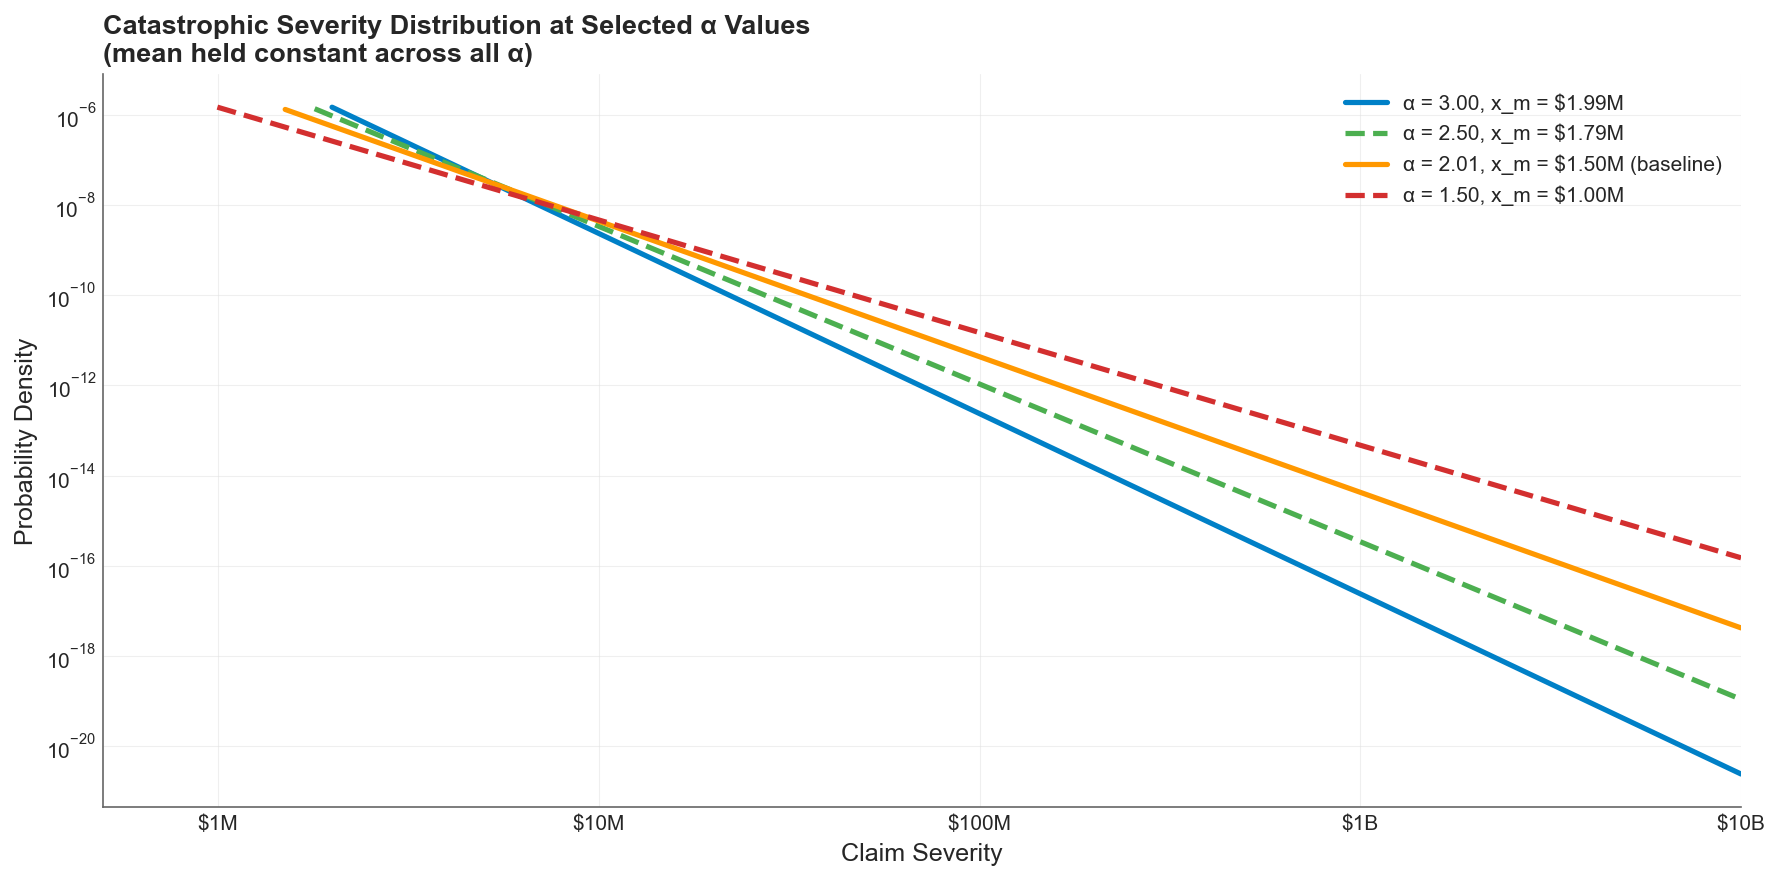

In [7]:
def dollar_fmt(x, pos):
    if x >= 1e9:  return f'${x/1e9:.0f}B'
    elif x >= 1e6: return f'${x/1e6:.0f}M'
    elif x >= 1e3: return f'${x/1e3:.0f}K'
    return f'${x:.0f}'

set_wsj_style()

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

xg = np.logspace(np.log10(500_000), 10, 5000)
highlight_alphas = [3.0, 2.5, CAT_SEV_ALPHA_BASELINE, 1.5]
highlight_colors = [COLOR_SEQUENCE[0], COLOR_SEQUENCE[2], COLOR_SEQUENCE[3], COLOR_SEQUENCE[1]]
highlight_styles = ['-', '--', '-', '--']

for alpha, color, ls in zip(highlight_alphas, highlight_colors, highlight_styles):
    xm = CAT_MEAN * (alpha - 1) / alpha
    mask = xg >= xm
    pdf = np.where(mask, alpha * xm**alpha * xg**(-alpha - 1), 0.0)
    lbl = f"\u03b1 = {alpha:.2f}, x_m = ${xm / 1e6:.2f}M"
    if abs(alpha - CAT_SEV_ALPHA_BASELINE) < 0.005:
        lbl += " (baseline)"
    ax.loglog(xg[mask], pdf[mask], color=color, lw=2.5, ls=ls, label=lbl)

ax.set_xlim(5e5, 1e10)
ax.set_xlabel("Claim Severity")
ax.set_ylabel("Probability Density")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))
ax.set_title("Catastrophic Severity Distribution at Selected \u03b1 Values\n"
             "(mean held constant across all \u03b1)",
             fontweight='bold', loc='left', fontsize=13)
ax.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.savefig("cache/plot_13_cat_severity_comparison.png", dpi=150,
            bbox_inches='tight')
plt.show()

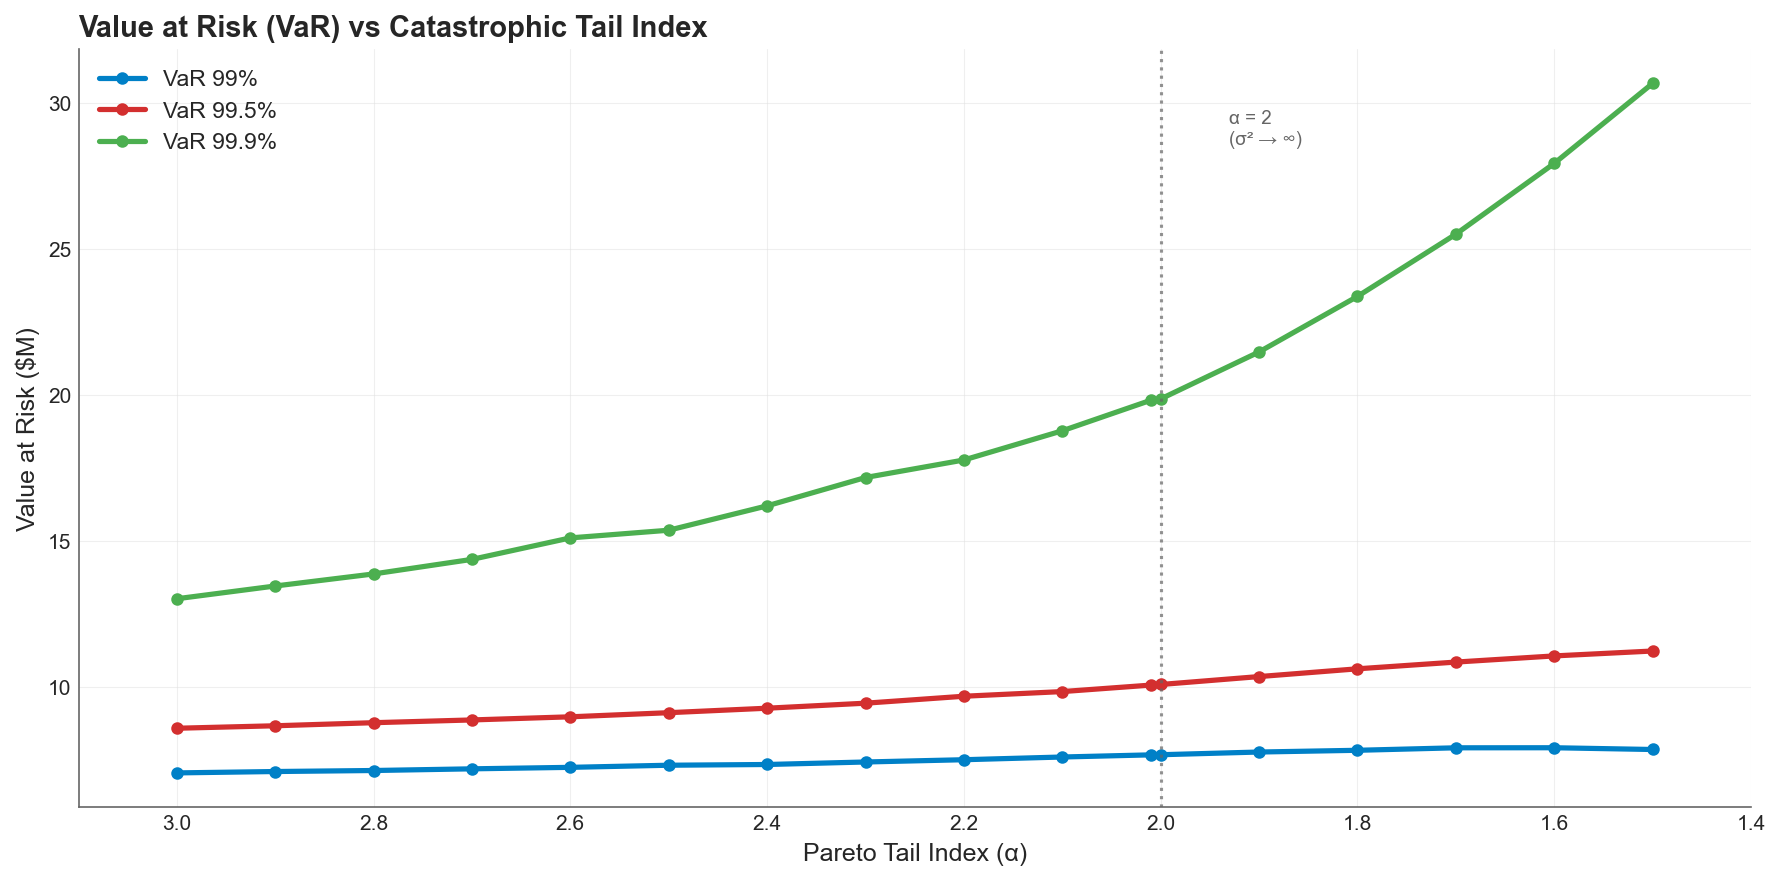

In [8]:
set_wsj_style()

def dollar_fmt(x, pos):
    if x >= 1e3: return f'${x:.0f}M'
    elif x >= 1:  return f'${x:.1f}M'
    return f'${x * 1e3:.0f}K'

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

for ci, (level, label) in enumerate(zip(CONFIDENCE_LEVELS, LEVEL_LABELS)):
    ax.plot(ALPHA_GRID, var_results[:, ci] / 1e6, 'o-',
            color=COLOR_SEQUENCE[ci], lw=2.5, ms=5, label=f'VaR {label}')

# Mark infinite-variance transition
ax.axvline(2.0, color=WSJ_COLORS['gray'], ls=':', lw=1.5, alpha=0.7)
trans = ax.get_xaxis_transform()
ax.text(1.93, 0.92, '\u03b1 = 2\n(\u03c3\u00b2 \u2192 \u221e)',
        fontsize=9, color=WSJ_COLORS['gray'],
        ha='left', va='top', transform=trans)

ax.set_xlabel('Pareto Tail Index (\u03b1)', fontsize=12)
ax.set_ylabel('Value at Risk ($M)', fontsize=12)
ax.set_title('Value at Risk (VaR) vs Catastrophic Tail Index',
             fontweight='bold', loc='left', fontsize=14)
ax.legend(fontsize=11)
ax.invert_xaxis()
ax.set_xlim(3.1, 1.4)
plt.tight_layout()
plt.savefig("cache/plot_13_var_by_alpha.png", dpi=150, bbox_inches='tight')
plt.show()

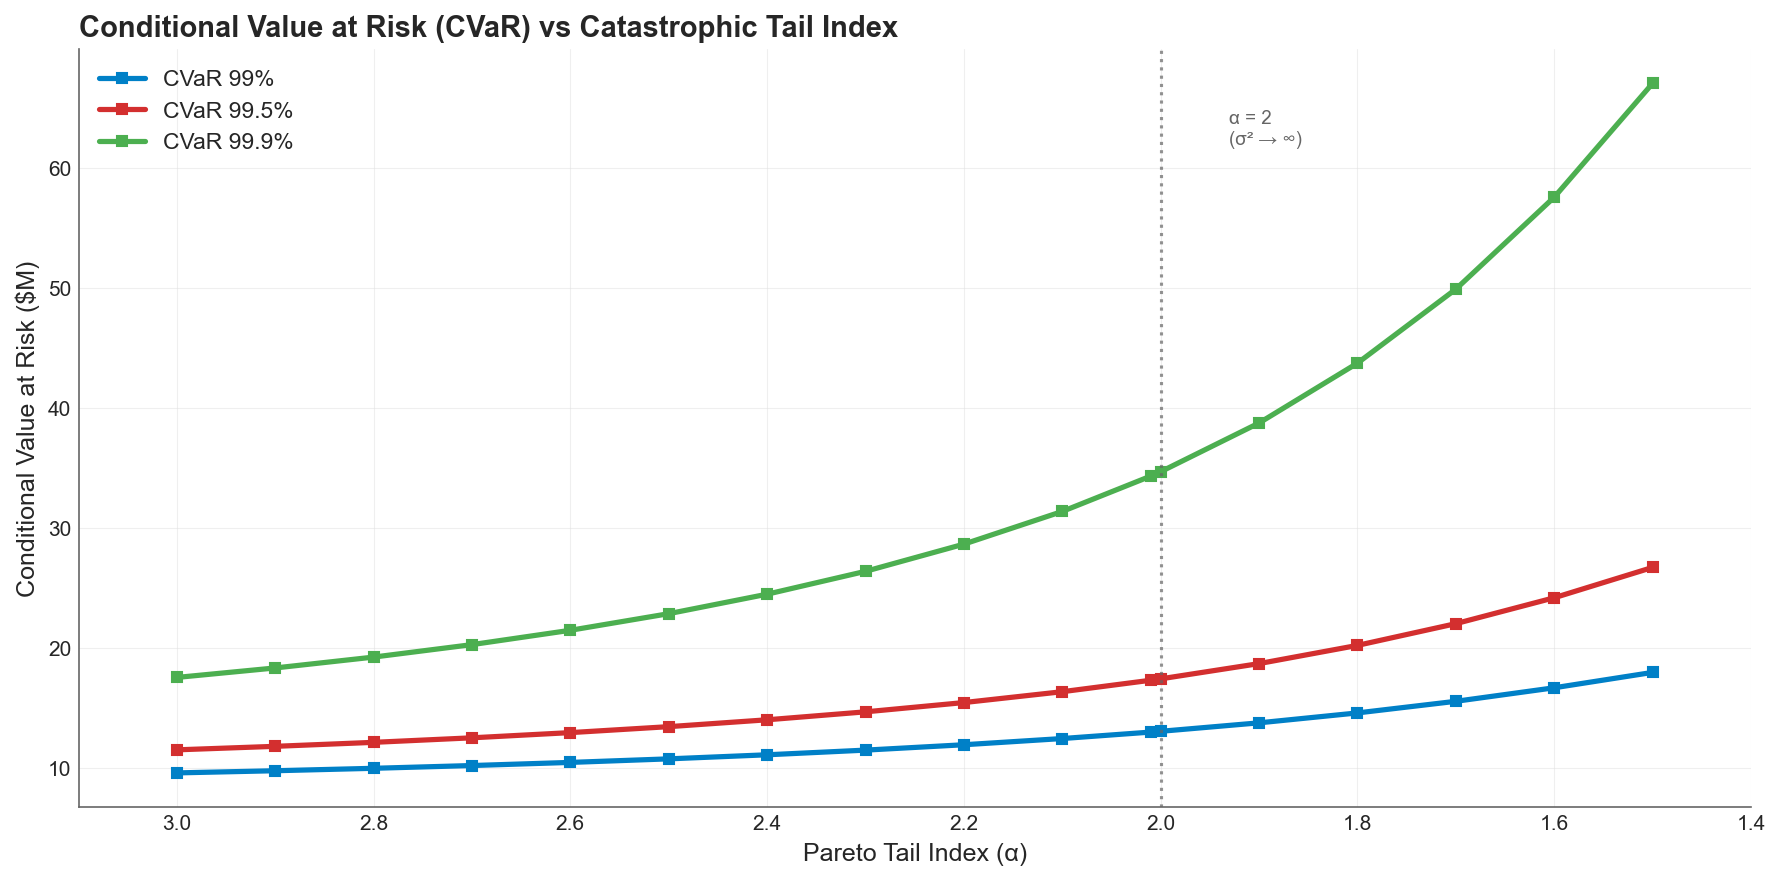

In [9]:
set_wsj_style()

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

for ci, (level, label) in enumerate(zip(CONFIDENCE_LEVELS, LEVEL_LABELS)):
    ax.plot(ALPHA_GRID, cvar_results[:, ci] / 1e6, 's-',
            color=COLOR_SEQUENCE[ci], lw=2.5, ms=5, label=f'CVaR {label}')

# Mark infinite-variance transition
ax.axvline(2.0, color=WSJ_COLORS['gray'], ls=':', lw=1.5, alpha=0.7)
trans = ax.get_xaxis_transform()
ax.text(1.93, 0.92, '\u03b1 = 2\n(\u03c3\u00b2 \u2192 \u221e)',
        fontsize=9, color=WSJ_COLORS['gray'],
        ha='left', va='top', transform=trans)

ax.set_xlabel('Pareto Tail Index (\u03b1)', fontsize=12)
ax.set_ylabel('Conditional Value at Risk ($M)', fontsize=12)
ax.set_title('Conditional Value at Risk (CVaR) vs Catastrophic Tail Index',
             fontweight='bold', loc='left', fontsize=14)
ax.legend(fontsize=11)
ax.invert_xaxis()
ax.set_xlim(3.1, 1.4)
plt.tight_layout()
plt.savefig("cache/plot_13_cvar_by_alpha.png", dpi=150, bbox_inches='tight')
plt.show()

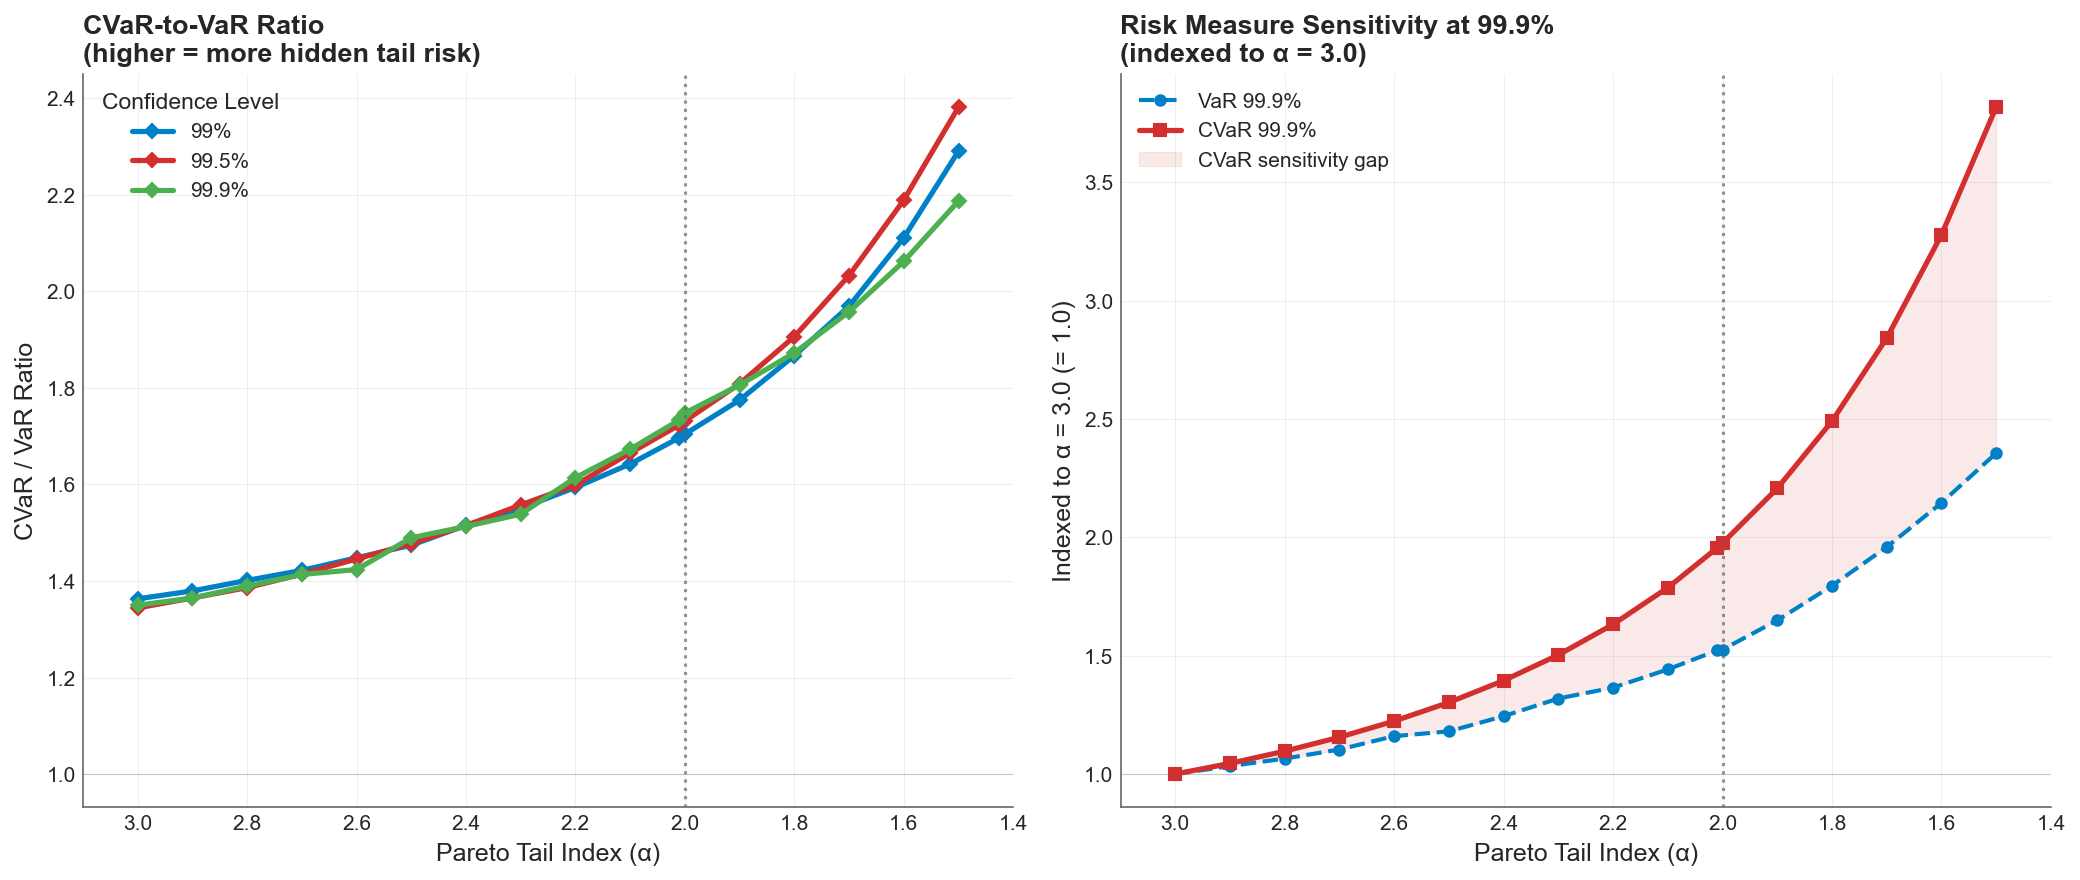

In [10]:
set_wsj_style()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

# --- Left: CVaR / VaR ratio ---
for ci, (level, label) in enumerate(zip(CONFIDENCE_LEVELS, LEVEL_LABELS)):
    ratio = cvar_results[:, ci] / var_results[:, ci]
    ax1.plot(ALPHA_GRID, ratio, 'D-', color=COLOR_SEQUENCE[ci], lw=2.5, ms=5,
             label=label)

ax1.axvline(2.0, color=WSJ_COLORS['gray'], ls=':', lw=1.5, alpha=0.7)
ax1.axhline(1.0, color=WSJ_COLORS['gray'], ls='-', lw=0.5, alpha=0.3)
ax1.set_xlabel('Pareto Tail Index (\u03b1)', fontsize=12)
ax1.set_ylabel('CVaR / VaR Ratio', fontsize=12)
ax1.set_title('CVaR-to-VaR Ratio\n(higher = more hidden tail risk)',
              fontweight='bold', loc='left', fontsize=13)
ax1.legend(fontsize=10, title='Confidence Level')
ax1.invert_xaxis()
ax1.set_xlim(3.1, 1.4)

# --- Right: Indexed sensitivity at 99.9% ---
ci_max = 2  # 99.9%
var_indexed = var_results[:, ci_max] / var_results[0, ci_max]
cvar_indexed = cvar_results[:, ci_max] / cvar_results[0, ci_max]

ax2.plot(ALPHA_GRID, var_indexed, 'o--', color=COLOR_SEQUENCE[0], lw=2, ms=5,
         label=f'VaR {LEVEL_LABELS[ci_max]}')
ax2.plot(ALPHA_GRID, cvar_indexed, 's-', color=COLOR_SEQUENCE[1], lw=2.5, ms=6,
         label=f'CVaR {LEVEL_LABELS[ci_max]}')
ax2.fill_between(ALPHA_GRID, var_indexed, cvar_indexed,
                 color=COLOR_SEQUENCE[1], alpha=0.10,
                 label='CVaR sensitivity gap')

ax2.axvline(2.0, color=WSJ_COLORS['gray'], ls=':', lw=1.5, alpha=0.7)
ax2.axhline(1.0, color=WSJ_COLORS['gray'], ls='-', lw=0.5, alpha=0.3)
ax2.set_xlabel('Pareto Tail Index (\u03b1)', fontsize=12)
ax2.set_ylabel('Indexed to \u03b1 = 3.0 (= 1.0)', fontsize=12)
ax2.set_title('Risk Measure Sensitivity at 99.9%\n(indexed to \u03b1 = 3.0)',
              fontweight='bold', loc='left', fontsize=13)
ax2.legend(fontsize=10)
ax2.invert_xaxis()
ax2.set_xlim(3.1, 1.4)

fig.tight_layout()
plt.savefig("cache/plot_13_sensitivity_comparison.png", dpi=150,
            bbox_inches='tight')
plt.show()

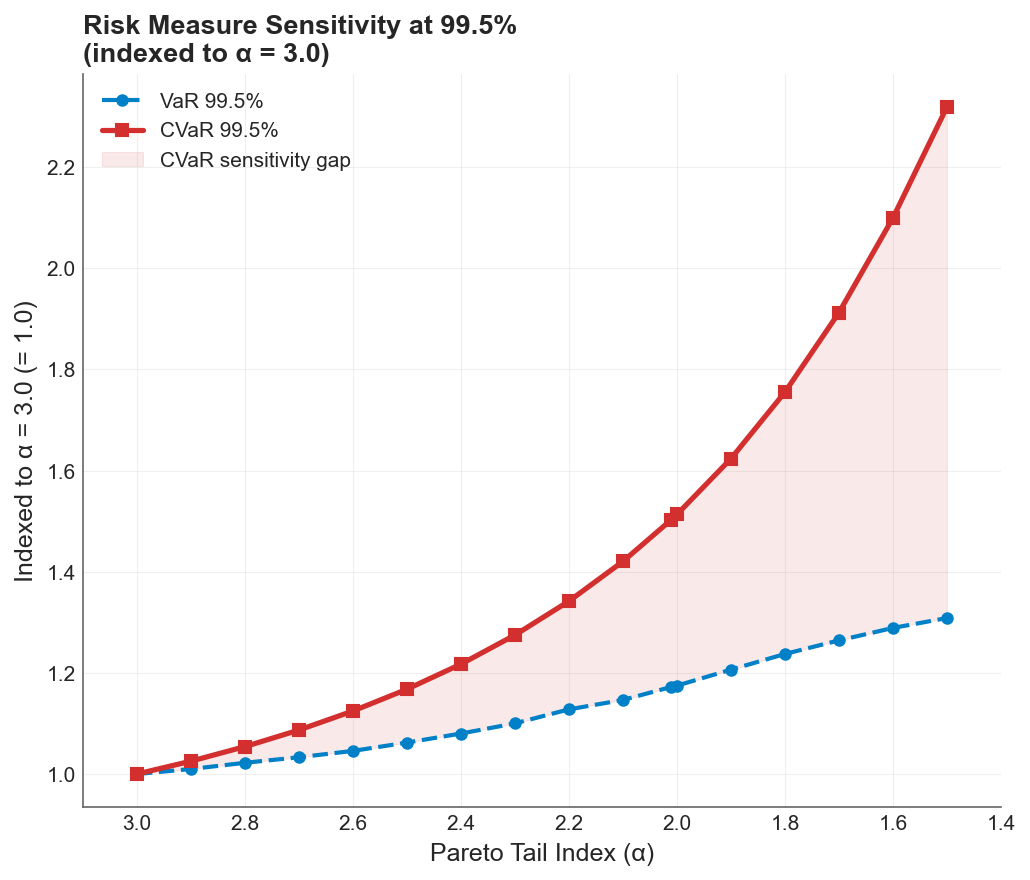

In [11]:
set_wsj_style()

fig, ax = plt.subplots(figsize=(7, 6), dpi=150)

# --- Indexed sensitivity at 99.5% ---
ci_max = 1  # 99.9%
var_indexed = var_results[:, ci_max] / var_results[0, ci_max]
cvar_indexed = cvar_results[:, ci_max] / cvar_results[0, ci_max]

ax.plot(ALPHA_GRID, var_indexed, 'o--', color=COLOR_SEQUENCE[0], lw=2, ms=5,
         label=f'VaR {LEVEL_LABELS[ci_max]}')
ax.plot(ALPHA_GRID, cvar_indexed, 's-', color=COLOR_SEQUENCE[1], lw=2.5, ms=6,
         label=f'CVaR {LEVEL_LABELS[ci_max]}')
ax.fill_between(ALPHA_GRID, var_indexed, cvar_indexed,
                 color=COLOR_SEQUENCE[1], alpha=0.10,
                 label='CVaR sensitivity gap')

ax.set_xlabel('Pareto Tail Index (\u03b1)', fontsize=12)
ax.set_ylabel('Indexed to \u03b1 = 3.0 (= 1.0)', fontsize=12)
ax.set_title('Risk Measure Sensitivity at 99.5%\n(indexed to \u03b1 = 3.0)',
              fontweight='bold', loc='left', fontsize=13)
ax.legend(fontsize=10)
ax.invert_xaxis()
ax.set_xlim(3.1, 1.4)

fig.tight_layout()
plt.savefig("cache/plot_13_sensitivity_99_5.png", dpi=150,
            bbox_inches='tight')
plt.show()

## Conclusion

### Summary

This experiment confirms that **CVaR (Expected Shortfall) is substantially more responsive to catastrophic tail risk than VaR**. As the Pareto tail index $\alpha$ decreases from 3.0 to 1.5 — fattening the catastrophic tail while keeping the mean loss constant — CVaR amplifies the signal far more than VaR at every confidence level tested.

### Quantitative Results

| Confidence Level | VaR Fold Increase | CVaR Fold Increase | CVaR Responsiveness |
|---|---|---|---|
| **99%** | 1.1$\times$ | 1.9$\times$ | 1.7$\times$ more responsive |
| **99.5%** | 1.3$\times$ | 2.3$\times$ | 1.8$\times$ more responsive |
| **99.9%** | 2.4$\times$ | 3.8$\times$ | 1.6$\times$ more responsive |

At the extremes: **VaR at 99.9% increased from \$13M to \$31M** (a 2.4$\times$ increase), while **CVaR at 99.9% surged from \$18M to \$67M** (a 3.8$\times$ increase). The CVaR-to-VaR ratio — measuring the "hidden" tail risk beyond VaR — rose from 1.35 at $\alpha = 3.0$ to 2.2 at $\alpha = 1.5$, a 1.6$\times$ expansion.

### Why This Happens

**VaR** is a quantile: it asks "what loss level will we exceed with probability $1{-}p$?" As the tail gets heavier, this threshold rises — but only gradually, because the quantile is a single point on the distribution. Even with infinite variance ($\alpha < 2$), VaR remains finite and grows relatively slowly. Critically, VaR at 99% barely moved (1.1$\times$), because 14% of years already have catastrophic events regardless of tail heaviness.

**CVaR** is a conditional mean: it asks "given that we've exceeded VaR, how bad will it be on average?" This captures the entire tail above VaR, including the extreme events that grow without bound as $\alpha \to 1$. When variance is infinite, CVaR picks up the signal that VaR fundamentally cannot.

### The $\alpha = 2$ Transition

The most important structural feature is the phase transition at $\alpha = 2$:

- For $\alpha > 2$, both VaR and CVaR increase as $\alpha$ decreases, but at comparable rates. The Pareto distribution has finite variance, so the tail is well-controlled.
- For $\alpha \leq 2$, variance becomes infinite. VaR continues its gradual climb (quantiles remain finite), but CVaR accelerates as the conditional tail mean now averages over an infinite-variance distribution. This divergence is visible in every plot: the CVaR curves steepen noticeably below $\alpha = 2$, while VaR curves remain nearly linear.

### Implications for Insurance Risk Management

1. **Risk measure selection matters.** A portfolio with $\alpha \approx 1.5$–$2.0$ catastrophic exposure looks modestly risky by VaR but dramatically risky by CVaR. Using VaR alone creates a dangerous blind spot for exactly the risks that can threaten solvency.

2. **Regulatory alignment.** Basel III and Solvency II have progressively shifted toward CVaR/Expected Shortfall as the primary risk measure, for precisely the reasons demonstrated here. Insurers and reinsurers operating under these frameworks should calibrate their internal models accordingly.

3. **Ergodic implications.** Under multiplicative dynamics, a company's time-average growth rate is most sensitive to the worst-case losses — the losses that CVaR measures. A seemingly efficient insurance program (low VaR) that neglects tail risk (high CVaR) can destroy long-run compounding even if the expected loss is small.

4. **Practical calibration.** The Pareto tail index $\alpha$ is empirically estimable from loss data (Hill estimator, maximum likelihood). For catastrophic exposures with $\alpha < 2.5$, CVaR should be the primary risk measure. For $\alpha < 2.0$ (common in natural catastrophe and cyber risk), VaR is essentially misleading as a tail risk indicator.